## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import re
import warnings
import os
import math

warnings.filterwarnings("ignore")


## 2. Data Ingestion

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
LOCAL_FILE = "/content/drive/MyDrive/en.openfoodfacts.org.products.csv"

if os.path.exists(LOCAL_FILE):
    print("File found.")
else:
    print("File not found — check the path above.")


File found.


In [4]:
COLS_TO_LOAD = [
    "product_name", "categories_tags", "ingredients_text",
    "sugars_100g", "proteins_100g", "fat_100g",
    "fiber_100g", "energy_100g", "nutriscore_grade", "countries_tags",
]

CHUNK_SIZE = 50_000
MAX_ROWS   = 150_000
chunks, rows_read = [], 0

for chunk in pd.read_csv(
    LOCAL_FILE, sep="\t", usecols=COLS_TO_LOAD,
    chunksize=CHUNK_SIZE, low_memory=True,
    encoding="utf-8", on_bad_lines="skip",
):
    chunks.append(chunk)
    rows_read += len(chunk)
    if rows_read >= MAX_ROWS:
        break

df_raw = pd.concat(chunks, ignore_index=True)
del chunks

print(f"Loaded {len(df_raw):,} rows x {df_raw.shape[1]} columns")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_raw.head(3)


Loaded 150,000 rows x 10 columns
Memory: 74.6 MB


,product_name,categories_tags,countries_tags,ingredients_text,nutriscore_grade,energy_100g,fat_100g,sugars_100g,fiber_100g,proteins_100g
0,Limonade artisanale a la rose,NaN,en:france,NaN,unknown,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,en:france,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",unknown,NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,NaN,en:france,NaN,unknown,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Report

In [5]:
total_rows = len(df_raw)
key_cols = ["product_name", "categories_tags", "sugars_100g",
            "proteins_100g", "fat_100g", "fiber_100g"]

print(f"Total rows: {total_rows:,}\n")
print(f"{'Column':<25} {'Missing':>10} {'% Missing':>12}")
print("-" * 50)
for col in key_cols:
    n = df_raw[col].isna().sum()
    print(f"{col:<25} {n:>10,} {n/total_rows*100:>11.1f}%")

print("\nNutrient ranges before cleaning:")
print(df_raw[["sugars_100g", "proteins_100g", "fat_100g", "fiber_100g"]]
      .describe().round(2).to_string())


Total rows: 150,000

Column                       Missing    % Missing
--------------------------------------------------
product_name                   7,339         4.9%
categories_tags               70,585        47.1%
sugars_100g                  122,484        81.7%
proteins_100g                121,320        80.9%
fat_100g                     121,394        80.9%
fiber_100g                   129,583        86.4%

Nutrient ranges before cleaning:
       sugars_100g  proteins_100g  fat_100g  fiber_100g
count     27516.00       28680.00  28606.00    20417.00
mean         12.45          11.06     12.66        4.10
std          21.22          39.94     48.53       47.36
min           0.00           0.00      0.00       -0.15
25%           1.20           2.35      1.00        0.44
50%           4.33           7.00      5.60        2.00
75%          15.80          12.00     17.10        4.17
max        1300.00        3500.00   4444.00     6636.00


## 4. Data Cleaning

In [6]:
df = df_raw.copy()
NUTRIENT_COLS = ["sugars_100g", "proteins_100g", "fat_100g", "fiber_100g"]

# Drop rows without the two nutrients central to this analysis
df.dropna(subset=["sugars_100g", "proteins_100g"], inplace=True)
df.dropna(subset=["product_name"], inplace=True)

# Cast to numeric and remove values outside the physically possible range
for col in NUTRIENT_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[(df[col].isna()) | ((df[col] >= 0) & (df[col] <= 100))]

# Fat and fiber are secondary — fill nulls rather than drop rows
df["fat_100g"].fillna(0, inplace=True)
df["fiber_100g"].fillna(0, inplace=True)

# Remove statistical outliers (3 x IQR) from the two axis nutrients
def remove_iqr_outliers(dataframe, col, multiplier=3.0):
    q1 = dataframe[col].quantile(0.25)
    q3 = dataframe[col].quantile(0.75)
    iqr = q3 - q1
    return dataframe[
        (dataframe[col] >= max(0, q1 - multiplier * iqr)) &
        (dataframe[col] <= q3 + multiplier * iqr)
    ]

df = remove_iqr_outliers(df, "sugars_100g")
df = remove_iqr_outliers(df, "proteins_100g")
df.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning: {len(df):,}  (removed {total_rows - len(df):,} | retention {len(df)/total_rows*100:.1f}%)")


Rows after cleaning: 25,082  (removed 124,918 | retention 16.7%)


In [7]:
print("Nutrient ranges after cleaning:")
print(df[["sugars_100g", "proteins_100g", "fat_100g", "fiber_100g"]]
      .describe().round(2).to_string())
print("\nNull check:", df[["product_name","sugars_100g","proteins_100g"]].isna().sum().to_dict())
df.head(5)


Nutrient ranges after cleaning:
       sugars_100g  proteins_100g  fat_100g  fiber_100g
count     25082.00       25082.00  25082.00    25082.00
mean         10.51           8.28     11.90        2.58
std          13.75           7.72     15.01        5.50
min           0.00           0.00      0.00        0.00
25%           1.19           2.44      1.13        0.00
50%           4.03           6.80      5.81        0.87
75%          14.04          11.00     17.83        3.30
max          59.52          39.60    100.00       90.00

Null check: {'product_name': 0, 'sugars_100g': 0, 'proteins_100g': 0}


,product_name,categories_tags,countries_tags,ingredients_text,nutriscore_grade,energy_100g,fat_100g,sugars_100g,fiber_100g,proteins_100g
0,Pinto Bean,en:asian-style-ready-meal,"en:united-kingdom,en:world",NaN,unknown,9.00,10.20000,4.900000,3.800000,17.500000
1,Croquetas de bacalao,NaN,en:spain,NaN,unknown,856.00,12.10000,1.900000,0.000000,5.900000
2,Keto & GF Granola,NaN,en:germany,NaN,unknown,2770.00,54.83871,3.225806,9.677419,19.677419
3,Ben's Pure Maple Cream,NaN,"en:france,en:world",NaN,unknown,2221.96,30.28000,37.720000,0.000000,5.680000
4,Thaï Red Curry (produit préparé),NaN,en:ireland,NaN,unknown,238.60,0.60000,1.200000,0.700000,1.400000


## 5. Category Classification

In [8]:
# Preview the raw tag format before building the classifier
print(df["categories_tags"].dropna().head(8).to_string())


0                             en:asian-style-ready-meal
5     en:beverages-and-beverages-preparations,en:bev...
12    en:plant-based-foods-and-beverages,en:plant-ba...
13    en:snacks,en:sweet-snacks,en:biscuits-and-cake...
15    en:breakfasts,en:spreads,en:sweet-spreads,fr:p...
16    en:plant-based-foods-and-beverages,en:plant-ba...
24    en:meats-and-their-products,en:meats,en:prepar...
25    en:meats-and-their-products,en:meats,en:prepar...


In [9]:
CATEGORY_RULES = [
    ("Chocolate & Candy",     ["chocolate","candy","confection","gummy","caramel","toffee","fudge"]),
    ("Biscuits & Cookies",    ["biscuit","cookie","cracker","wafer","shortbread","brownie"]),
    ("Chips & Crisps",        ["chip","crisp","puff","popcorn","pretzel","corn-snack","rice-cake"]),
    ("Bars & Granola",        ["bar","granola","cereal-bar","protein-bar","energy-bar","muesli"]),
    ("Nuts & Seeds",          ["nut","seed","almond","peanut","cashew","pistachio","walnut","pecan"]),
    ("Dairy Snacks",          ["dairy","cheese","yogurt","yoghurt","milk-snack","fromage"]),
    ("Fruit & Veggie Snacks", ["fruit","vegetable","veggie","dried-fruit","apple-snack","banana"]),
]
FALLBACK_CATEGORY = "Other Snacks"

def assign_primary_category(tags_string):
    if pd.isna(tags_string) or not isinstance(tags_string, str):
        return FALLBACK_CATEGORY
    cleaned = re.sub(r'\b[a-z]{2}:', '', tags_string.lower())
    for category_name, keywords in CATEGORY_RULES:
        for kw in keywords:
            if kw in cleaned:
                return category_name
    return FALLBACK_CATEGORY

df["primary_category"] = df["categories_tags"].apply(assign_primary_category)

cat_counts = df["primary_category"].value_counts()
print(f"{'Category':<25} {'Count':>8} {'%':>7}")
print("-" * 42)
for cat, count in cat_counts.items():
    print(f"{cat:<25} {count:>8,} {count/len(df)*100:>6.1f}%")


Category                     Count       %
------------------------------------------
Other Snacks                19,670   78.4%
Dairy Snacks                 1,244    5.0%
Fruit & Veggie Snacks        1,207    4.8%
Nuts & Seeds                   735    2.9%
Biscuits & Cookies             708    2.8%
Chocolate & Candy              619    2.5%
Chips & Crisps                 561    2.2%
Bars & Granola                 338    1.3%


In [10]:
# Spot-check: confirm products landed in the right buckets
for cat in cat_counts.index[:6]:
    samples = df[df["primary_category"] == cat]["product_name"].dropna().head(3).tolist()
    print(f"[{cat}]  {' | '.join(samples)}")


[Other Snacks]  Pinto Bean | Croquetas de bacalao | Keto & GF Granola
[Dairy Snacks]  greek yogurt | 26 38 | Greek Nonfat Yogurt
[Fruit & Veggie Snacks]  boisson à l'aloe vera | น้ำยาพ่นคอ | Born fruta fresca deshidratada
[Nuts & Seeds]  pumpkin seeds | Tarte noix de coco | Dark Chocolate Turbinado Sea Salt Almonds
[Biscuits & Cookies]  Donut Milka | Cigarettes Fourrées Chocolat Noisettes | Brins de framboise
[Chocolate & Candy]  Véritable pâte à tartiner noisettes chocolat noir | Food Grade Corn | Pain au chocolat pur beurre x10


## 6. Nutritional Summary by Category

In [11]:
summary = df.groupby("primary_category").agg(
    products    = ("product_name",  "count"),
    avg_sugar   = ("sugars_100g",   "mean"),
    avg_protein = ("proteins_100g", "mean"),
    avg_fat     = ("fat_100g",      "mean"),
    avg_fiber   = ("fiber_100g",    "mean"),
).round(2).sort_values("avg_protein", ascending=False)

print(summary.to_string())


                       products  avg_sugar  avg_protein  avg_fat  avg_fiber
primary_category                                                           
Nuts & Seeds                735       7.38        12.59    29.10       4.44
Bars & Granola              338      22.63         8.90    12.63       5.76
Other Snacks              19670       9.83         8.67    10.98       2.58
Dairy Snacks               1244       7.42         8.35     7.99       0.51
Chips & Crisps              561       3.74         7.01    22.54       3.91
Biscuits & Cookies          708      20.09         6.83    18.32       2.75
Chocolate & Candy           619      32.86         5.54    21.37       2.91
Fruit & Veggie Snacks      1207       9.44         1.99     6.71       1.89


## 7. Nutrient Matrix — Sugar vs. Protein

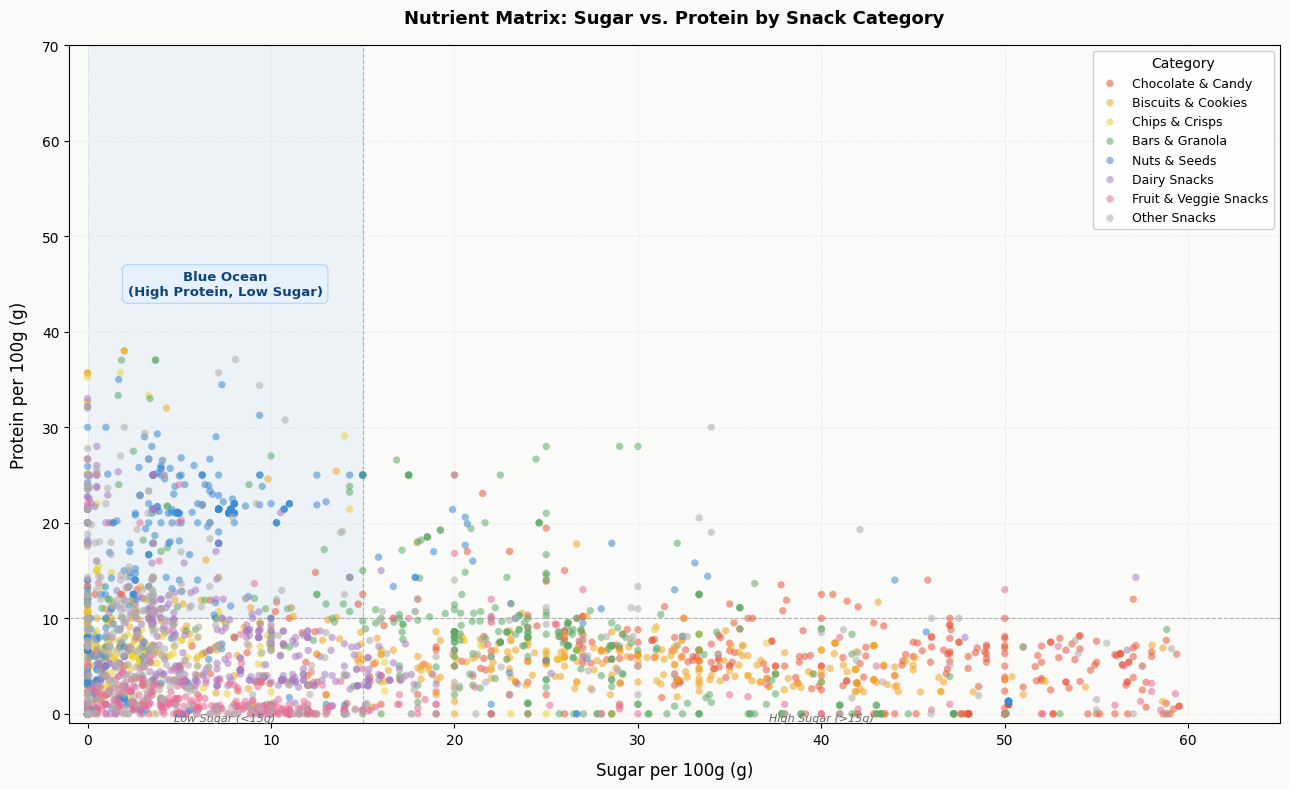

In [12]:
CATEGORY_COLORS = {
    "Chocolate & Candy":     "#E8593C",
    "Biscuits & Cookies":    "#F2A623",
    "Chips & Crisps":        "#EDD234",
    "Bars & Granola":        "#5DAA67",
    "Nuts & Seeds":          "#3B8BD4",
    "Dairy Snacks":          "#A77DC2",
    "Fruit & Veggie Snacks": "#E76F9A",
    "Other Snacks":          "#B0ADAA",
}

df_sample = df.groupby("primary_category", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 400), random_state=42)
)

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#FAFAF8")

for cat, color in CATEGORY_COLORS.items():
    subset = df_sample[df_sample["primary_category"] == cat]
    ax.scatter(subset["sugars_100g"], subset["proteins_100g"],
               color=color, alpha=0.55, s=28, edgecolors="none", label=cat, zorder=3)

ax.axvline(x=15, color="#888", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(y=10, color="#888", linewidth=0.8, linestyle="--", alpha=0.6)
ax.fill_betweenx(y=[10, 70], x1=0, x2=15, alpha=0.07, color="#3B8BD4", label="_nolegend_")
ax.text(7.5, 45, "Blue Ocean\n(High Protein, Low Sugar)",
        ha="center", va="center", fontsize=9.5, color="#0C447C", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#E6F1FB", ec="#B5D4F4", lw=0.8))

ax.set_xlabel("Sugar per 100g (g)", fontsize=12, labelpad=10)
ax.set_ylabel("Protein per 100g (g)", fontsize=12, labelpad=10)
ax.set_title("Nutrient Matrix: Sugar vs. Protein by Snack Category", fontsize=13, fontweight="bold", pad=16)
ax.set_xlim(-1, 65)
ax.set_ylim(-1, 70)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.grid(True, linestyle=":", color="#DDDDDD", linewidth=0.6, zorder=0)
ax.legend(title="Category", fontsize=9, loc="upper right", framealpha=0.9, edgecolor="#CCCCCC")
ax.text(7.5, -0.8, "Low Sugar (<15g)", ha="center", fontsize=8, color="#666", style="italic")
ax.text(40,  -0.8, "High Sugar (>15g)", ha="center", fontsize=8, color="#666", style="italic")

plt.tight_layout()
plt.savefig("nutrient_matrix_static.png", dpi=160, bbox_inches="tight")
plt.show()


In [13]:
df_plot = df.groupby("primary_category", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 600), random_state=42)
).copy()

fig_interactive = px.scatter(
    df_plot,
    x="sugars_100g", y="proteins_100g",
    color="primary_category",
    hover_name="product_name",
    hover_data={
        "sugars_100g": ":.1f", "proteins_100g": ":.1f",
        "fat_100g": ":.1f", "fiber_100g": ":.1f",
        "primary_category": False,
    },
    color_discrete_map=CATEGORY_COLORS, opacity=0.65,
    labels={
        "sugars_100g": "Sugar per 100g (g)",
        "proteins_100g": "Protein per 100g (g)",
        "primary_category": "Category",
    },
    title="Nutrient Matrix — Sugar vs. Protein by Snack Category",
    template="plotly_white",
)

fig_interactive.add_vline(x=15, line_dash="dash", line_color="#999999", line_width=1.2)
fig_interactive.add_hline(y=10, line_dash="dash", line_color="#999999", line_width=1.2)
fig_interactive.add_shape(type="rect", x0=0, x1=15, y0=10, y1=70,
                           fillcolor="rgba(59,139,212,0.08)", line=dict(width=0), layer="below")
fig_interactive.add_annotation(x=7.5, y=50,
    text="<b>Blue Ocean</b><br>High Protein + Low Sugar", showarrow=False,
    font=dict(size=11, color="#185FA5"), bgcolor="rgba(230,241,251,0.85)",
    bordercolor="#B5D4F4", borderwidth=1, borderpad=6)
fig_interactive.update_layout(
    xaxis_range=[-1, 65], yaxis_range=[-1, 70],
    legend_title_text="Category",
    margin=dict(l=60, r=40, t=60, b=60),
    plot_bgcolor="#FAFAF8", paper_bgcolor="#FAFAF8",
)

fig_interactive.show()
fig_interactive.write_html("nutrient_matrix_interactive.html")


## 8. Blue Ocean Quadrant & Recommendation

In [14]:
SUGAR_THRESHOLD   = 15
PROTEIN_THRESHOLD = 10

def label_quadrant(row):
    hi_p = row["proteins_100g"] >= PROTEIN_THRESHOLD
    lo_s = row["sugars_100g"]   <= SUGAR_THRESHOLD
    if hi_p and lo_s:     return "High Protein + Low Sugar (Blue Ocean)"
    if hi_p and not lo_s: return "High Protein + High Sugar"
    if not hi_p and lo_s: return "Low Protein + Low Sugar"
    return                       "Low Protein + High Sugar"

df["quadrant"] = df.apply(label_quadrant, axis=1)

quadrant_counts = df["quadrant"].value_counts()
for q, n in quadrant_counts.items():
    print(f"  {q:<48} {n:>6,}  ({n/len(df)*100:.1f}%)")

blue_ocean_df = df[df["quadrant"] == "High Protein + Low Sugar (Blue Ocean)"]
blue_by_cat   = blue_ocean_df["primary_category"].value_counts()

print("\nBlue Ocean count by category:")
print(blue_by_cat.to_string())

best_category  = blue_by_cat.index[0]
target_profile = blue_ocean_df[
    blue_ocean_df["primary_category"] == best_category
][["sugars_100g", "proteins_100g", "fat_100g", "fiber_100g"]].median().round(1)

best_protein = target_profile["proteins_100g"]
best_sugar   = target_profile["sugars_100g"]

INSIGHT_TEXT = (
    f"Based on the data, the biggest market opportunity is in "
    f"{best_category}, specifically targeting products with "
    f"~{best_protein}g of protein and less than {best_sugar}g of sugar per 100g."
)

print(f"\nRecommendation: {INSIGHT_TEXT}")


  Low Protein + Low Sugar                          12,372  (49.3%)
  High Protein + Low Sugar (Blue Ocean)             6,768  (27.0%)
  Low Protein + High Sugar                          5,025  (20.0%)
  High Protein + High Sugar                           917  (3.7%)

Blue Ocean count by category:
primary_category
Other Snacks             5793
Nuts & Seeds              361
Dairy Snacks              328
Biscuits & Cookies        127
Chips & Crisps             52
Bars & Granola             51
Fruit & Veggie Snacks      30
Chocolate & Candy          26

Recommendation: Based on the data, the biggest market opportunity is in Other Snacks, specifically targeting products with ~15.0g of protein and less than 1.8g of sugar per 100g.


## 9. Bonus — Top Protein Source Ingredients

In [15]:
PROTEIN_KEYWORDS = [
    "whey", "peanut", "soy", "soya", "almond", "cashew",
    "protein", "egg", "milk protein", "casein", "hemp",
    "pea protein", "sunflower seed", "chia", "quinoa",
    "chickpea", "lentil", "walnut", "pistachio",
]

hp_products = df[
    (df["proteins_100g"] >= PROTEIN_THRESHOLD) &
    (df["sugars_100g"]   <= SUGAR_THRESHOLD)   &
    (df["ingredients_text"].notna())
].copy()

print(f"Products analysed: {len(hp_products):,}")

keyword_counts = Counter()
for ingredients in hp_products["ingredients_text"].str.lower():
    for kw in PROTEIN_KEYWORDS:
        if kw in str(ingredients):
            keyword_counts[kw] += 1

top_ingredients = keyword_counts.most_common(10)

print(f"\n{'Rank':<5} {'Ingredient':<20} {'Count':>7} {'%':>7}")
print("-" * 42)
for rank, (ingredient, count) in enumerate(top_ingredients, 1):
    print(f"{rank:<5} {ingredient:<20} {count:>7,} {count/len(hp_products)*100:>6.1f}%")

TOP_3_PROTEINS = [kw.title() for kw, _ in top_ingredients[:3]]
print(f"\nTop 3: {TOP_3_PROTEINS}")


Products analysed: 2,848

Rank  Ingredient             Count       %
------------------------------------------
1     soy                      717   25.2%
2     protein                  386   13.6%
3     whey                     347   12.2%
4     egg                      166    5.8%
5     peanut                   131    4.6%
6     sunflower seed            98    3.4%
7     almond                    91    3.2%
8     milk protein              84    2.9%
9     quinoa                    59    2.1%
10    pistachio                 59    2.1%

Top 3: ['Soy', 'Protein', 'Whey']


In [16]:
labels = [kw.title() for kw, _ in top_ingredients[:8]]
counts = [cnt for _, cnt in top_ingredients[:8]]

fig_ingr = go.Figure(go.Bar(
    x=counts, y=labels, orientation="h",
    marker=dict(color=counts, colorscale=[[0,"#B5D4F4"],[1,"#0C447C"]], showscale=False),
    text=[f"{c:,}" for c in counts], textposition="outside",
))
fig_ingr.update_layout(
    title="Top Protein Sources in High-Protein / Low-Sugar Snacks",
    xaxis_title="Number of products containing ingredient",
    yaxis=dict(autorange="reversed"),
    template="plotly_white",
    margin=dict(l=120, r=60, t=60, b=60),
    plot_bgcolor="#FAFAF8", paper_bgcolor="#FAFAF8",
)
fig_ingr.show()
fig_ingr.write_html("protein_sources.html")


## 10. Market Opportunity Score

A composite score to rank categories by investment priority. Three signals are weighted together: how large the supply gap is (50%), whether consumers are already seeking protein in this space (30%), and how big the category is overall (20%). This converts the scatter plot observation into a ranked, boardroom-ready output.

In [17]:
opportunity_rows = []

for cat in df["primary_category"].unique():
    cat_df  = df[df["primary_category"] == cat]
    n_total = len(cat_df)
    if n_total < 50:
        continue

    n_blue_ocean = len(cat_df[
        (cat_df["proteins_100g"] >= PROTEIN_THRESHOLD) &
        (cat_df["sugars_100g"]   <= SUGAR_THRESHOLD)
    ])
    gap_pct      = 1 - (n_blue_ocean / n_total)
    demand_proxy = min(cat_df["proteins_100g"].quantile(0.80) / 40.0, 1.0)
    mkt_size     = math.log10(n_total) / math.log10(df["primary_category"].value_counts().max())
    score        = (gap_pct * 0.50) + (demand_proxy * 0.30) + (mkt_size * 0.20)

    opportunity_rows.append({
        "Category":           cat,
        "Total Products":     n_total,
        "Blue Ocean Count":   n_blue_ocean,
        "Gap %":              round(gap_pct * 100, 1),
        "Demand Score":       round(demand_proxy, 3),
        "Market Size Score":  round(mkt_size, 3),
        "Opportunity Score":  round(score, 3),
        "Avg Sugar":          round(cat_df["sugars_100g"].mean(), 1),
        "Avg Protein":        round(cat_df["proteins_100g"].mean(), 1),
    })

opp_df = pd.DataFrame(opportunity_rows).sort_values("Opportunity Score", ascending=False).reset_index(drop=True)
opp_df.index += 1
print(opp_df.to_string())


                Category  Total Products  Blue Ocean Count  Gap %  Demand Score  Market Size Score  Opportunity Score  Avg Sugar  Avg Protein
1      Chocolate & Candy             619                26   95.8         0.202              0.650              0.670       32.9          5.5
2           Other Snacks           19670              5793   70.5         0.333              1.000              0.653        9.8          8.7
3  Fruit & Veggie Snacks            1207                30   97.5         0.068              0.718              0.652        9.4          2.0
4         Chips & Crisps             561                52   90.7         0.182              0.640              0.636        3.7          7.0
5         Bars & Granola             338                51   84.9         0.312              0.589              0.636       22.6          8.9
6     Biscuits & Cookies             708               127   82.1         0.250              0.664              0.618       20.1          6.8
7     

In [18]:
cats_sorted   = opp_df["Category"].tolist()
scores_sorted = opp_df["Opportunity Score"].tolist()
bar_colors    = ["#185FA5" if c == cats_sorted[0] else "#B5D4F4" for c in cats_sorted]

fig_opp = go.Figure()
for i, (cat, score) in enumerate(zip(cats_sorted, scores_sorted)):
    fig_opp.add_shape(type="line", x0=0, x1=score, y0=i, y1=i,
                      line=dict(color=bar_colors[i], width=2))

fig_opp.add_trace(go.Scatter(
    x=scores_sorted, y=cats_sorted,
    mode="markers+text",
    marker=dict(size=14, color=bar_colors, line=dict(color="white", width=1.5)),
    text=[f"{s:.2f}" for s in scores_sorted],
    textposition="middle right",
    textfont=dict(size=11, color="#333"),
))
fig_opp.update_layout(
    title={"text": "Market Opportunity Score by Snack Category<br>"
                   "<sup>Gap Size 50% | Demand Proxy 30% | Market Size 20%</sup>", "x": 0.5},
    xaxis=dict(title="Opportunity Score (0-1)", range=[0, 1.15], showgrid=True, gridcolor="#EEEEEE"),
    yaxis=dict(autorange="reversed", tickfont=dict(size=12)),
    showlegend=False,
    margin=dict(l=180, r=80, t=90, b=60),
    plot_bgcolor="#FAFAF8", paper_bgcolor="#FAFAF8",
    template="plotly_white", height=420,
)
fig_opp.add_annotation(x=scores_sorted[0], y=0, text="  #1 Opportunity",
                        showarrow=False, font=dict(size=11, color="#185FA5"), xanchor="left")
fig_opp.show()
fig_opp.write_html("opportunity_score.html")


## 11. Export

In [19]:
df.to_csv("sugar_trap_clean_data.csv", index=False)
opp_df.to_csv("opportunity_scores.csv", index=True)

print(f"sugar_trap_clean_data.csv  — {len(df):,} rows")
print("opportunity_scores.csv     — opportunity scorecard")
print("nutrient_matrix_static.png")
print("nutrient_matrix_interactive.html")
print("protein_sources.html")
print("opportunity_score.html")


sugar_trap_clean_data.csv  — 25,082 rows
opportunity_scores.csv     — opportunity scorecard
nutrient_matrix_static.png
nutrient_matrix_interactive.html
protein_sources.html
opportunity_score.html
